In [ ]:
!pip install torch torchvision scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
!cp -r /content/drive/MyDrive/COS30082Project/realDATA/classification_data /content/classification_data


In [ ]:
import os, time, random
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import torchvision
from tqdm.auto import tqdm

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
data_dir = '/content/drive/MyDrive/COS30082Project/realDATA/classification_data'
ckpt_dir = '/content/drive/MyDrive/COS30082Project/checkpoints'

Transforms for classification

In [ ]:
batch_size = 64
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

DataLoaders

In [ ]:
all_classes = [d for d in os.listdir(os.path.join(data_dir,'train_data')) if os.path.isdir(os.path.join(data_dir,'train_data',d))]
num_subset = min(1200, len(all_classes))
selected_classes = all_classes[:num_subset]
print(f"Training classification on {num_subset}/{len(all_classes)} classes")

Training classification on 1200/3832 classes


In [ ]:
def make_filtered_dataset(root, transform, classes):
    ds = datasets.ImageFolder(root, transform)
    new_samples = []
    for path,label in ds.samples:
        cls_name = ds.classes[label]
        if cls_name in classes:
            new_label = classes.index(cls_name)
            new_samples.append((path, new_label))
    ds.samples = new_samples
    ds.classes = classes
    ds.class_to_idx = {c:i for i,c in enumerate(classes)}
    return ds

In [ ]:
train_ds = make_filtered_dataset(os.path.join(data_dir,'train_data'), train_transform, selected_classes)
val_ds   = make_filtered_dataset(os.path.join(data_dir,'val_data'),   val_transform,   selected_classes)
test_ds  = make_filtered_dataset(os.path.join(data_dir,'test_data'),  val_transform,   selected_classes)

In [ ]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


##CNN model


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),  nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),  #64->32
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),  #32->16
            nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),  #16->8
            nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2)  #8->4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256*4*4,512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512,num_classes)
        )
    def forward(self,x):
        x = self.features(x)
        return self.classifier(x)

Instantiate

In [ ]:
num_classes = len(selected_classes)
cls_model = SimpleCNN(num_classes).to(device)
print('Model architecture:', cls_model)

Model architecture: SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track

Train classification model (Supervised Classfication)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cls_model.parameters(), lr=1e-3, weight_decay=1e-4)  # weight_decay = L2 regularization
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
epochs = 50
loss_hist, acc_hist = [], []

In [ ]:
for ep in range(1,epochs+1):
    start = time.time()
    cls_model.train()
    total_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f"[Cls] Ep {ep}/{epochs}", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = cls_model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    scheduler.step()

    # Validation
    cls_model.eval(); correct=total=0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            pred = cls_model(imgs).argmax(dim=1)
            correct += (pred==labels).sum().item(); total += labels.size(0)
    val_acc = 100*correct/total
    loss_hist.append(avg_loss); acc_hist.append(val_acc)
    print(f"[Cls] Ep {ep}/{epochs} Loss {avg_loss:.4f} ValAcc {val_acc:.2f}% Time {time.time()-start:.1f}s")

[Cls] Ep 1/50:   0%|          | 0/1794 [00:00<?, ?it/s]

[Cls] Ep 1/50 Loss 7.0744 ValAcc 0.08% Time 12507.3s


[Cls] Ep 2/50:   0%|          | 0/1794 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ae7c87d2ac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ae7c87d2ac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 16

[Cls] Ep 2/50 Loss 7.0481 ValAcc 0.08% Time 305.4s


...

[Cls] Ep 48/50 Loss 4.7545 ValAcc 16.12% Time 309.4s


[Cls] Ep 49/50:   0%|          | 0/1794 [00:00<?, ?it/s]

[Cls] Ep 49/50 Loss 4.7577 ValAcc 16.00% Time 309.6s


[Cls] Ep 50/50:   0%|          | 0/1794 [00:00<?, ?it/s]

[Cls] Ep 50/50 Loss 4.7571 ValAcc 16.12% Time 307.7s


Test accuracy evaluation

In [ ]:
cls_model.eval(); test_correct=test_total=0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        pred = cls_model(imgs).argmax(dim=1)
        test_correct += (pred==labels).sum().item(); test_total += labels.size(0)
print(f"[Cls] Test Acc: {100*test_correct/test_total:.2f}%")

[Cls] Test Acc: 17.29%


checkpoint

In [ ]:
# Save trained classification model so it can be reloaded after disconnects
cls_state_path = os.path.join(ckpt_dir, 'cls_model_final_checkpoint_1.pth')
torch.save(cls_model.state_dict(), cls_state_path)
print(f"Saved classification model state dict to: {cls_state_path}")
#full model
cls_full_path = os.path.join(ckpt_dir, 'cls_model_full_checkpoint_1.pt')
torch.save(cls_model, cls_full_path)
print(f"Saved full classification model to: {cls_full_path}")

Saved classification model state dict to: /content/drive/MyDrive/COS30082Project/checkpoints/cls_model_final_checkpoint_1.pth
Saved full classification model to: /content/drive/MyDrive/COS30082Project/checkpoints/cls_model_full_checkpoint_1.pt


Embeddings extractor

In [ ]:
cls_embed = nn.Sequential(*list(cls_model.children())[:-1], nn.Flatten()).to(device)

Training Metric Learning (Triplet Loss)

In [ ]:
class TripletDataset(Dataset):
    def __init__(self, root, transform):
        self.transform = transform
        # 1) collect only classes with ≥2 valid images
        self.classes = []
        self.paths   = {}
        for c in sorted(os.listdir(root)):
            cls_dir = os.path.join(root, c)
            if not os.path.isdir(cls_dir):
                continue
            imgs = [f for f in os.listdir(cls_dir)
                    if os.path.isfile(os.path.join(cls_dir, f))
                    and f.lower().endswith(('.jpg','.jpeg','.png'))]
            if len(imgs) < 2:
                continue
            self.classes.append(c)
            self.paths[c] = [os.path.join(cls_dir, f) for f in imgs]

        # 2) flatten anchor list
        self.samples = [(p, c) for c, ps in self.paths.items() for p in ps]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        anc_path, anc_cls = self.samples[idx]
        # positive
        pos_path = random.choice([p for p in self.paths[anc_cls] if p != anc_path])
        # negative from a different class
        neg_cls  = random.choice([c for c in self.classes if c != anc_cls])
        neg_path = random.choice(self.paths[neg_cls])

        def load(p):
            img = torchvision.io.read_image(p).float() / 255.0
            img = transforms.ToPILImage()(img)
            return self.transform(img)

        return load(anc_path), load(pos_path), load(neg_path)


In [ ]:
trip_ds = TripletDataset(os.path.join(data_dir,'train_data'), train_transform)
trip_loader = DataLoader(trip_ds, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)

In [ ]:
a, p, n = trip_ds[0]
print('Anchor shape:', a.shape, 'Positive shape:', p.shape, 'Negative shape:', n.shape)

Anchor shape: torch.Size([3, 64, 64]) Positive shape: torch.Size([3, 64, 64]) Negative shape: torch.Size([3, 64, 64])


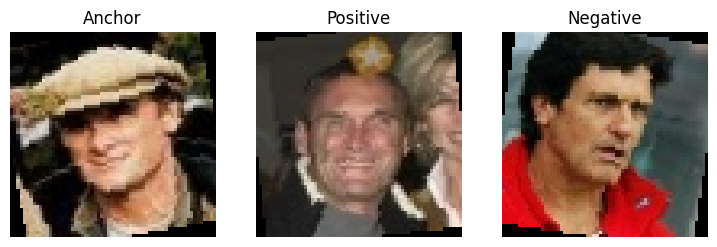

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,3, figsize=(9,3))
for img, ax, title in zip([a,p,n], axes, ['Anchor','Positive','Negative']):
    img_np = img.permute(1,2,0).numpy()
    ax.imshow((img_np * 0.5 + 0.5))
    ax.set_title(title)
    ax.axis('off')
plt.show()

Embedding network (same SimpleCNN backbone)

In [ ]:
embed_net = nn.Sequential(
    cls_model.features,
    nn.Flatten(),
    # 256*4*4 = 4096 features
    nn.Linear(256*4*4, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
).to(device)


In [ ]:
triplet_loss = nn.TripletMarginLoss(margin=1.0)
opt2 = optim.Adam(embed_net.parameters(), lr=1e-4)

actual training metric learning

In [ ]:
for ep in range(1,epochs+1):
    start=time.time(); embed_net.train(); tot=0
    for a,p,n in trip_loader:
        a,p,n=[x.to(device) for x in (a,p,n)]
        opt2.zero_grad()
        ea,epos,en = embed_net(a), embed_net(p), embed_net(n)
        loss=triplet_loss(ea,epos,en)
        loss.backward(); opt2.step()
        tot+=loss.item()
    print(f"[Trip] Ep {ep}/{epochs} Loss {tot/len(trip_loader):.4f} Time {time.time()-start:.1f}s")

[Trip] Ep 1/50 Loss 0.3158 Time 25596.9s
[Trip] Ep 2/50 Loss 0.2805 Time 3313.2s


KeyboardInterrupt: 

checkpoint

In [ ]:
# Save triplet embedding model after training
tri_state = os.path.join(ckpt_dir, 'tri_embed_net_final_checkpoint_1.pth')
torch.save(embed_net.state_dict(), tri_state)
print(f"Saved triplet embedding state dict to: {tri_state}")
tri_full = os.path.join(ckpt_dir, 'tri_embed_net_full_checkpoint_1.pt')
torch.save(embed_net, tri_full)
print(f"Saved full triplet embedding model to: {tri_full}")

Saved triplet embedding state dict to: /content/drive/MyDrive/COS30082Project/checkpoints/incompletetri_embed_net_final_checkpoint_2Epoch.pth
Saved full triplet embedding model to: /content/drive/MyDrive/COS30082Project/checkpoints/incompletetri_embed_net_full_checkpoint_2Epoch.pt


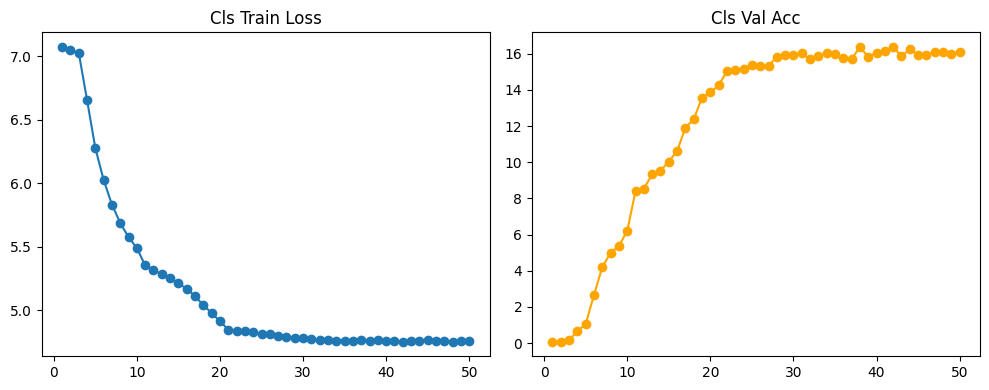

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(range(1,epochs+1), loss_hist, 'o-'); plt.title('Cls Train Loss')
plt.subplot(1,2,2); plt.plot(range(1,epochs+1), acc_hist, 'o-', color='orange'); plt.title('Cls Val Acc')
plt.tight_layout(); plt.show()

# Identification Top-1 Accuracy

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

In [ ]:
def extract_embeddings(model, loader, embed_dim=None):
    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            out = model(imgs).cpu().numpy()
            feats.append(out)
            labels.extend(lbls.numpy())
    feats = np.vstack(feats)
    labels = np.array(labels)
    return feats, labels

Create DataLoaders without augmentation for embedding extraction

In [ ]:
de_emb_transform = val_transform
train_ds_eval = datasets.ImageFolder(os.path.join(data_dir,'train_data'), de_emb_transform)
val_ds_eval   = datasets.ImageFolder(os.path.join(data_dir,'val_data'),   de_emb_transform)
train_loader_eval = DataLoader(train_ds_eval, batch_size=64, shuffle=False, num_workers=4)
val_loader_eval   = DataLoader(val_ds_eval,   batch_size=64, shuffle=False, num_workers=4)

NameError: name 'val_transform' is not defined

In [ ]:
train_embs_cls, train_lbls = extract_embeddings(cls_embed, train_loader_eval)
val_embs_cls,   val_lbls   = extract_embeddings(cls_embed, val_loader_eval)
train_embs_tri, _          = extract_embeddings(embed_net, train_loader_eval)
val_embs_tri,   _          = extract_embeddings(embed_net, val_loader_eval)

NameError: name 'extract_embeddings' is not defined

1-NN for classification embeddings

In [ ]:
knn_cls = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn_cls.fit(train_embs_cls, train_lbls)
acc_cls_knn = knn_cls.score(val_embs_cls, val_lbls)

NameError: name 'KNeighborsClassifier' is not defined

1-NN for triplet embeddings

In [ ]:
knn_tri = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn_tri.fit(train_embs_tri, train_lbls)
acc_tri_knn = knn_tri.score(val_embs_tri, val_lbls)

#Results

In [ ]:
print(f"Top-1 Identification Accuracy:\n"
      f"  Classification Embeddings: {acc_cls_knn*100:.2f}%")
print(f"Triplet Embeddings:         {acc_tri_knn*100:.2f}%")


#Saving

In [ ]:
torch.save(cls_model.state_dict(), os.path.join(ckpt_dir, 'cnnV1.1_state_dict.pth'))
torch.save(cls_model,           os.path.join(ckpt_dir, 'cnnV1.1.pt'))

Embedding network state dict and full model

In [ ]:
torch.save(embed_net.state_dict(), os.path.join(ckpt_dir, 'embed_cnnV1.1_state_dict.pth'))
torch.save(embed_net,              os.path.join(ckpt_dir, 'embed_cnnV1.1.pt'))